In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.linalg import expm
import os
from scipy.stats import norm, expon
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
 
print("=" * 70)
print("  CHAPITRE 4 — CT-HMM : Détection d'Intrusions (CICIDS2017)")
print("  Modèles de Markov Cachés à Temps Continu")
print("=" * 70)

  CHAPITRE 4 — CT-HMM : Détection d'Intrusions (CICIDS2017)
  Modèles de Markov Cachés à Temps Continu


#  PARTIE 0 : Chargement CICIDS2017


In [4]:
DOSSIER = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\MachineLearningCVE'
 
FICHIERS = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
]
 
def mapper_label(label):
    if not isinstance(label, str):
        return 'other'
    label = label.strip()
    if label == 'BENIGN':                                          return 'benign'
    elif any(x in label for x in ['DoS','Heartbleed']):           return 'dos'
    elif any(x in label for x in ['PortScan','FTP-Patator','SSH-Patator']): return 'probe'
    elif 'Bot' in label:                                           return 'botnet'
    elif 'DDoS' in label:                                          return 'ddos'
    elif any(x in label for x in ['Web Attack','XSS','Brute Force','Sql']): return 'web'
    elif 'Infiltration' in label:                                  return 'infiltration'
    else:                                                          return 'other'
 
def charger_fichier_complet(chemin, max_par_cat=800):
    """
    Charge le fichier entier puis échantillonne intelligemment :
    - max_par_cat lignes BENIGN
    - toutes les lignes d'attaque disponibles
    """
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(chemin, low_memory=False,
                             encoding=enc, on_bad_lines='skip')
            df.columns = df.columns.str.strip()
            label_col = next((c for c in df.columns
                              if c.strip().lower() == 'label'), None)
            if label_col is None:
                continue
            df['Label'] = df[label_col].astype(str).str.strip()
            df['attack_cat'] = df['Label'].apply(mapper_label)
            for feat in ['Flow Duration','Flow Bytes/s','Flow Packets/s',
                         'Flow IAT Mean','Total Fwd Packets']:
                if feat in df.columns:
                    df[feat] = pd.to_numeric(df[feat], errors='coerce')
 
            # Garder max_par_cat benign + toutes les attaques
            benign   = df[df['attack_cat']=='benign'].head(max_par_cat)
            attaques = df[df['attack_cat']!='benign']
            return pd.concat([benign, attaques], ignore_index=True)
        except Exception:
            continue
    return None
 
print("=" * 65)
print("  Chargement CICIDS2017 — lecture complète des 8 fichiers")
print("=" * 65)
 
dfs = []
for fichier in FICHIERS:
    chemin = os.path.join(DOSSIER, fichier)
    if not os.path.exists(chemin):
        print(f"  ❌ {fichier[:50]}")
        continue
    df_tmp = charger_fichier_complet(chemin, max_par_cat=800)
    if df_tmp is None or len(df_tmp) == 0:
        print(f"  ❌ Échec : {fichier[:50]}")
        continue
    cats = df_tmp['attack_cat'].value_counts().to_dict()
    dfs.append(df_tmp)
    cats_str = '  '.join(f"{k}:{v}" for k,v in cats.items())
    print(f"  ✅ {fichier[:48]:<48s} [{cats_str}]")
 
if not dfs:
    raise RuntimeError("Aucun fichier chargé !")
 
df_raw = pd.concat(dfs, ignore_index=True)
 
# Préparer
OBS_FEATURE = 'Flow Duration'
df_raw = df_raw[df_raw[OBS_FEATURE].notna() & (df_raw[OBS_FEATURE] > 0)]
df_raw['obs_log']    = np.log1p(df_raw[OBS_FEATURE])
df_raw['etat_cache'] = df_raw['attack_cat'].apply(
    lambda x: 0 if x == 'benign' else 1)
 
n_b = (df_raw['etat_cache']==0).sum()
n_a = (df_raw['etat_cache']==1).sum()
print(f"\n  Avant sélection : Normal={n_b}  Attaque={n_a}")
 
if n_a == 0:
    raise RuntimeError("❌ Toujours 0 attaque — les attaques sont peut-être après la ligne 800")
 
# Équilibrer : garder au max 3000 benign + toutes les attaques
benign_sample  = df_raw[df_raw['etat_cache']==0].sample(
    n=min(3000, n_b), random_state=42)
attaque_sample = df_raw[df_raw['etat_cache']==1]
df = pd.concat([benign_sample, attaque_sample]).sample(
    frac=1, random_state=42).reset_index(drop=True)
 
print(f"\n{'='*65}")
print(f"  ✅ Dataset final : {len(df):,} flux réseau")
print(f"{'='*65}")
print(f"\n  Distribution des catégories :")
for cat, cnt in df['attack_cat'].value_counts().items():
    pct = cnt/len(df)*100
    barre = '█' * int(pct/3)
    print(f"    {cat:14s} : {cnt:5d}  ({pct:5.1f}%)  {barre}")
 
print(f"\n  États cachés CT-HMM :")
for i, nom in {0:'Normal', 1:'Attaque'}.items():
    cnt = (df['etat_cache']==i).sum()
    print(f"    État {i} — {nom:10s} : {cnt:5d}  ({cnt/len(df)*100:.1f}%)")
 
print(f"\n  Statistiques log(Flow Duration) :")
for i, nom in {0:'Normal', 1:'Attaque'}.items():
    vals = df[df['etat_cache']==i]['obs_log'].values
    if len(vals) > 0:
        print(f"    {nom:10s} : μ={np.mean(vals):.4f}  σ={np.std(vals):.4f}  n={len(vals)}")
 
save_csv = os.path.join(DOSSIER, 'cicids2017_clean.csv')
df.to_csv(save_csv, index=False)
print(f"\n  ✅ cicids2017_clean.csv sauvegardé ({len(df)} lignes)")

  Chargement CICIDS2017 — lecture complète des 8 fichiers
  ✅ Monday-WorkingHours.pcap_ISCX.csv                [benign:800]
  ✅ Tuesday-WorkingHours.pcap_ISCX.csv               [probe:13835  benign:800]
  ✅ Wednesday-workingHours.pcap_ISCX.csv             [dos:252672  benign:800]
  ✅ Thursday-WorkingHours-Morning-WebAttacks.pcap_IS [web:2180  benign:800]
  ✅ Thursday-WorkingHours-Afternoon-Infilteration.pc [benign:800  infiltration:36]
  ✅ Friday-WorkingHours-Morning.pcap_ISCX.csv        [botnet:1966  benign:800]
  ✅ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv [dos:128027  benign:800]
  ✅ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX [probe:158930  benign:800]

  Avant sélection : Normal=6378  Attaque=556556

  ✅ Dataset final : 559,556 flux réseau

  Distribution des catégories :
    dos            : 379748  ( 67.9%)  ██████████████████████
    probe          : 172636  ( 30.9%)  ██████████
    benign         :  3000  (  0.5%)  
    web            :  2180  (  0.4%)  
    botnet

#  PARTIE 1 : Introduction CT-HMM — États cachés et observations continues


In [5]:
print("\n" + "=" * 70)
print("PARTIE 1 — Introduction CT-HMM : États & Observations Continues")
print("=" * 70)
 
# États cachés
ETATS = {0: "Normal", 1: "Attaque"}
N = 2
 
# Observations CONTINUES (pas discrètes comme Ch3)
# On utilise Flow Duration comme feature principale (distribuée exponentiellement)
OBS_FEATURE = 'Flow Duration'
 
# Assigner les états cachés
df['etat_cache'] = df['attack_cat'].apply(lambda x: 0 if x == 'benign' else 1)
 
# Nettoyer et normaliser Flow Duration
df[OBS_FEATURE] = pd.to_numeric(df[OBS_FEATURE], errors='coerce').fillna(0)
df = df[df[OBS_FEATURE] > 0].reset_index(drop=True)
 
# Log-transformation (rend la distribution plus gaussienne)
df['obs_log'] = np.log1p(df[OBS_FEATURE])
 
print(f"""
  Différence fondamentale avec le Chapitre 3 (DT-HMM) :
  ┌──────────────────────────────┬──────────────────────────────────────┐
  │ DT-HMM (Ch3) — NSL-KDD      │ CT-HMM (Ch4) — CICIDS2017            │
  ├──────────────────────────────┼──────────────────────────────────────┤
  │ Temps discret t=1,2,3,...    │ Temps continu t ∈ ℝ+                 │
  │ Matrice A (probabilités)     │ Matrice Q (taux de transition)        │
  │ Émissions discrètes B(i,k)   │ Émissions continues f(x|μᵢ,σᵢ)      │
  │ Durée dans état : géom.      │ Durée dans état : Exp(qᵢ)            │
  │ Observations : F/M/E         │ Observations : Flow Duration (µs)     │
  └──────────────────────────────┴──────────────────────────────────────┘
 
  États cachés S = {{S0: Normal, S1: Attaque}}   N = {N}
  Observation continue : log(1 + Flow Duration) ∈ ℝ+
""")
 
print(f"  Statistiques de l'observation (log Flow Duration) :")
for i, nom in ETATS.items():
    vals = df[df['etat_cache']==i]['obs_log'].values
    print(f"    {nom:10s} : μ={np.mean(vals):.4f}  σ={np.std(vals):.4f}  "
          f"n={len(vals)}")
 


PARTIE 1 — Introduction CT-HMM : États & Observations Continues

  Différence fondamentale avec le Chapitre 3 (DT-HMM) :
  ┌──────────────────────────────┬──────────────────────────────────────┐
  │ DT-HMM (Ch3) — NSL-KDD      │ CT-HMM (Ch4) — CICIDS2017            │
  ├──────────────────────────────┼──────────────────────────────────────┤
  │ Temps discret t=1,2,3,...    │ Temps continu t ∈ ℝ+                 │
  │ Matrice A (probabilités)     │ Matrice Q (taux de transition)        │
  │ Émissions discrètes B(i,k)   │ Émissions continues f(x|μᵢ,σᵢ)      │
  │ Durée dans état : géom.      │ Durée dans état : Exp(qᵢ)            │
  │ Observations : F/M/E         │ Observations : Flow Duration (µs)     │
  └──────────────────────────────┴──────────────────────────────────────┘
 
  États cachés S = {S0: Normal, S1: Attaque}   N = 2
  Observation continue : log(1 + Flow Duration) ∈ ℝ+

  Statistiques de l'observation (log Flow Duration) :
    Normal     : μ=10.6596  σ=5.3039  n=3000
    

#  PARTIE 2 : Paramètres CT-HMM λ = (Q, f_cont, π)


In [6]:
print("\n" + "=" * 70)
print("PARTIE 2 — Paramètres CT-HMM λ = (Q, f_cont, π)")
print("=" * 70)
 
# ── Matrice génératrice Q (N×N) ──
# q_ij = taux de transition i→j  (i≠j)
# q_ii = -Σ_{j≠i} q_ij
# Estimé depuis les durées moyennes dans chaque état
 
# Durée moyenne dans chaque état → λi = 1/E[Ti]
durees = {}
for i in range(N):
    mask = df['etat_cache'] == i
    dur_i = df[mask][OBS_FEATURE].values
    dur_i = dur_i[dur_i > 0]
    durees[i] = np.mean(dur_i) if len(dur_i) > 0 else 1.0
 
q0 = 1.0 / durees[0]   # taux de sortie de Normal
q1 = 1.0 / durees[1]   # taux de sortie de Attaque
 
# Matrice de transition embedded (comme Ch2 CTMC)
counts_trans = np.zeros((N, N))
etats_seq = df['etat_cache'].values
for t in range(len(etats_seq)-1):
    i, j = int(etats_seq[t]), int(etats_seq[t+1])
    if i != j:
        counts_trans[i, j] += 1
 
p_emb = counts_trans.copy()
for i in range(N):
    s = p_emb[i].sum()
    if s > 0:
        p_emb[i] /= s
    else:
        p_emb[i] = np.array([0.5, 0.5])
        p_emb[i, i] = 0
 
# Q = diag(-qi) + qi * P_emb
Q = np.zeros((N, N))
rates = [q0, q1]
for i in range(N):
    for j in range(N):
        if i != j:
            Q[i, j] = rates[i] * p_emb[i, j]
    Q[i, i] = -rates[i]
 
# ── Paramètres des émissions gaussiennes f(x|μi, σi) ──
mu_emit  = np.zeros(N)
sig_emit = np.zeros(N)
for i in range(N):
    vals = df[df['etat_cache']==i]['obs_log'].values
    mu_emit[i]  = np.mean(vals)
    sig_emit[i] = np.std(vals) + 1e-6
 
# ── Distribution initiale π ──
pi = np.array([
    (df['etat_cache']==0).sum() / len(df),
    (df['etat_cache']==1).sum() / len(df)
])
 
print(f"""
  Matrice génératrice Q (q_ij = taux de transition i→j) :
         Normal      Attaque
  Normal  {Q[0,0]:.6f}   {Q[0,1]:.6f}
  Attaque {Q[1,0]:.6f}  {Q[1,1]:.6f}
 
  Interprétation :
    q_00 = {Q[0,0]:.6f} → intensité de sortie de Normal (durée moy. = {1/q0:.0f} µs)
    q_11 = {Q[1,1]:.6f} → intensité de sortie d'Attaque (durée moy. = {1/q1:.0f} µs)
    q_01 = {Q[0,1]:.6f} → taux Normal → Attaque
    q_10 = {Q[1,0]:.6f} → taux Attaque → Normal
 
  Vérification Σ_j q_ij = 0 :
    Ligne Normal   : {Q[0].sum():.2e}  ✓
    Ligne Attaque  : {Q[1].sum():.2e}  ✓
 
  Probabilités de transition P(t) = e^{{Qt}} à t=1000µs :
""")
 
Pt = expm(Q * 1000)
print(f"    P(1000µs) = [[{Pt[0,0]:.6f}  {Pt[0,1]:.6f}]")
print(f"                 [{Pt[1,0]:.6f}  {Pt[1,1]:.6f}]]")
 
print(f"""
  Émissions continues f(x|état) = N(μ, σ²) sur log(Flow Duration) :
    Normal   : μ = {mu_emit[0]:.4f},  σ = {sig_emit[0]:.4f}
    Attaque  : μ = {mu_emit[1]:.4f},  σ = {sig_emit[1]:.4f}
 
  Distribution initiale π :
    π(Normal)  = {pi[0]:.4f}  ({pi[0]*100:.1f}%)
    π(Attaque) = {pi[1]:.4f}  ({pi[1]*100:.1f}%)
""")


PARTIE 2 — Paramètres CT-HMM λ = (Q, f_cont, π)

  Matrice génératrice Q (q_ij = taux de transition i→j) :
         Normal      Attaque
  Normal  -0.000000   0.000000
  Attaque 0.000000  -0.000000
 
  Interprétation :
    q_00 = -0.000000 → intensité de sortie de Normal (durée moy. = 16278570 µs)
    q_11 = -0.000000 → intensité de sortie d'Attaque (durée moy. = 29374224 µs)
    q_01 = 0.000000 → taux Normal → Attaque
    q_10 = 0.000000 → taux Attaque → Normal
 
  Vérification Σ_j q_ij = 0 :
    Ligne Normal   : 0.00e+00  ✓
    Ligne Attaque  : 0.00e+00  ✓
 
  Probabilités de transition P(t) = e^{Qt} à t=1000µs :

    P(1000µs) = [[0.999939  0.000061]
                 [0.000034  0.999966]]

  Émissions continues f(x|état) = N(μ, σ²) sur log(Flow Duration) :
    Normal   : μ = 10.6596,  σ = 5.3039
    Attaque  : μ = 10.8989,  σ = 6.6291
 
  Distribution initiale π :
    π(Normal)  = 0.0054  (0.5%)
    π(Attaque) = 0.9946  (99.5%)



#  PARTIE 3 : Fonction d'émission continue


In [7]:
print("=" * 70)
print("PARTIE 3 — Émissions Continues f(x|μᵢ, σᵢ)")
print("=" * 70)
print(f"""
  Dans DT-HMM : B(i,k) = P(O_t=k | X_t=i)  → probabilité discrète
  Dans CT-HMM : f(x|i) = N(x; μᵢ, σᵢ²)    → densité gaussienne
 
  Formule : f(x|i) = 1/(σᵢ√2π) · exp(-(x-μᵢ)²/(2σᵢ²))
 
  Probabilités d'émission pour quelques valeurs de log(Flow Duration) :
""")
 
def emit_prob(x, mu, sig):
    """Densité gaussienne N(x; mu, sig)."""
    return norm.pdf(x, loc=mu, scale=sig)
 
# Exemples
x_exemples = [5.0, 7.0, 9.0, 11.0, 13.0]
print(f"  {'x=log(FD)':>12s}  {'f(x|Normal)':>14s}  {'f(x|Attaque)':>14s}  {'Ratio N/A':>10s}")
for x in x_exemples:
    f0 = emit_prob(x, mu_emit[0], sig_emit[0])
    f1 = emit_prob(x, mu_emit[1], sig_emit[1])
    ratio = f0/(f1+1e-300)
    print(f"  {x:>12.1f}  {f0:>14.6f}  {f1:>14.6f}  {ratio:>10.3f}")

PARTIE 3 — Émissions Continues f(x|μᵢ, σᵢ)

  Dans DT-HMM : B(i,k) = P(O_t=k | X_t=i)  → probabilité discrète
  Dans CT-HMM : f(x|i) = N(x; μᵢ, σᵢ²)    → densité gaussienne
 
  Formule : f(x|i) = 1/(σᵢ√2π) · exp(-(x-μᵢ)²/(2σᵢ²))
 
  Probabilités d'émission pour quelques valeurs de log(Flow Duration) :

     x=log(FD)     f(x|Normal)    f(x|Attaque)   Ratio N/A
           5.0        0.042566        0.040505       1.051
           7.0        0.059284        0.050622       1.171
           9.0        0.071623        0.057761       1.240
          11.0        0.075062        0.060174       1.247
          13.0        0.068239        0.057232       1.192


#  PARTIE 4 : Algorithme de Forward continu α


In [8]:
print("\n" + "=" * 70)
print("PARTIE 4 — Algorithme de Forward Continu α_t(i)")
print("=" * 70)
print("""
  Adaptation CT-HMM :
  α_t(i) = P(O_1,...,O_t, X_t=i | λ)
 
  Initialisation : α_1(i) = π_i · f(O_1|i)
  Récurrence     : α_{t+1}(j) = [Σ_i α_t(i) · P(Δt)_ij] · f(O_{t+1}|j)
                   où P(Δt) = e^{Q·Δt}  (lien avec Chapitre 2 CTMC)
  Finalisation   : P(O|λ) = Σ_i α_T(i)
 
  Différence clé vs DT-HMM :
    DT-HMM  : α_{t+1}(j) = [Σ_i α_t(i) · a_ij] · B_j(O_{t+1})
    CT-HMM  : α_{t+1}(j) = [Σ_i α_t(i) · P(Δt)_ij] · f(O_{t+1}|j)
    → A remplacé par P(Δt) = e^{Q·Δt}
    → B(j,k) remplacé par f(O_{t+1}|j) densité gaussienne
""")
 
def forward_ct(obs_log_seq, duree_seq, Q, mu, sig, pi):
    """
    Forward continu pour CT-HMM.
    obs_log_seq : séquence de log(Flow Duration) (continues)
    duree_seq   : durées entre observations (Δt)
    Q           : matrice génératrice
    mu, sig     : paramètres gaussiens par état
    """
    T = len(obs_log_seq)
    N = Q.shape[0]
    alpha = np.zeros((T, N))
 
    # Initialisation
    for i in range(N):
        alpha[0, i] = pi[i] * emit_prob(obs_log_seq[0], mu[i], sig[i])
 
    # Récurrence
    for t in range(1, T):
        dt = max(duree_seq[t], 1e-6)
        Pt = expm(Q * dt)   # P(Δt) = e^{Q·Δt}
        for j in range(N):
            alpha[t, j] = np.sum(alpha[t-1] * Pt[:, j]) * \
                          emit_prob(obs_log_seq[t], mu[j], sig[j])
 
    prob = alpha[-1].sum()
    return alpha, prob
 
# Séquence de test : 15 premiers flux CICIDS2017
T_test = 15
obs_test  = df['obs_log'].values[:T_test]
duree_test = df[OBS_FEATURE].values[:T_test]
etats_test = df['etat_cache'].values[:T_test]
 
alpha_ct, prob_fwd = forward_ct(obs_test, duree_test, Q, mu_emit, sig_emit, pi)
 
print(f"  Séquence de test ({T_test} premiers flux CICIDS2017) :")
print(f"  log(Flow Duration) = {[f'{x:.2f}' for x in obs_test]}")
print(f"  États réels        = {[ETATS[e] for e in etats_test]}")
print(f"\n  Matrice α forward (T×N) :")
print(f"  {'t':>4s}  {'α_t(Normal)':>16s}  {'α_t(Attaque)':>16s}  {'Obs x_t':>10s}")
for t in range(T_test):
    print(f"  {t+1:>4d}  {alpha_ct[t,0]:>16.4e}  {alpha_ct[t,1]:>16.4e}  "
          f"{obs_test[t]:>10.4f}")
print(f"\n  P(O|λ) = Σ_i α_T(i) = {prob_fwd:.4e}")


PARTIE 4 — Algorithme de Forward Continu α_t(i)

  Adaptation CT-HMM :
  α_t(i) = P(O_1,...,O_t, X_t=i | λ)
 
  Initialisation : α_1(i) = π_i · f(O_1|i)
  Récurrence     : α_{t+1}(j) = [Σ_i α_t(i) · P(Δt)_ij] · f(O_{t+1}|j)
                   où P(Δt) = e^{Q·Δt}  (lien avec Chapitre 2 CTMC)
  Finalisation   : P(O|λ) = Σ_i α_T(i)
 
  Différence clé vs DT-HMM :
    DT-HMM  : α_{t+1}(j) = [Σ_i α_t(i) · a_ij] · B_j(O_{t+1})
    CT-HMM  : α_{t+1}(j) = [Σ_i α_t(i) · P(Δt)_ij] · f(O_{t+1}|j)
    → A remplacé par P(Δt) = e^{Q·Δt}
    → B(j,k) remplacé par f(O_{t+1}|j) densité gaussienne

  Séquence de test (15 premiers flux CICIDS2017) :
  log(Flow Duration) = ['1.61', '15.22', '4.26', '18.23', '18.26', '18.07', '4.32', '3.09', '16.30', '3.47', '18.26', '1.39', '13.44', '14.53', '13.94']
  États réels        = ['Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque']

  Matrice α forwar

#  PARTIE 5 : Algorithme de Backward continu β


In [9]:
print("\n" + "=" * 70)
print("PARTIE 5 — Algorithme de Backward Continu β_t(i)")
print("=" * 70)
print("""
  β_t(i) = P(O_{t+1},...,O_T | X_t=i, λ)
 
  Initialisation : β_T(i) = 1
  Récurrence     : β_t(i) = Σ_j P(Δt)_ij · f(O_{t+1}|j) · β_{t+1}(j)
  Finalisation   : P(O|λ) = Σ_i π_i · f(O_1|i) · β_1(i)
""")
 
def backward_ct(obs_log_seq, duree_seq, Q, mu, sig, pi):
    T = len(obs_log_seq)
    N = Q.shape[0]
    beta = np.zeros((T, N))
    beta[-1] = 1.0
 
    for t in range(T-2, -1, -1):
        dt = max(duree_seq[t+1], 1e-6)
        Pt = expm(Q * dt)
        for i in range(N):
            beta[t, i] = np.sum(
                Pt[i, :] * np.array([emit_prob(obs_log_seq[t+1], mu[j], sig[j])
                                     for j in range(N)]) * beta[t+1, :]
            )
 
    prob = np.sum(pi * np.array([emit_prob(obs_log_seq[0], mu[i], sig[i])
                                  for i in range(N)]) * beta[0, :])
    return beta, prob
 
beta_ct, prob_bwd = backward_ct(obs_test, duree_test, Q, mu_emit, sig_emit, pi)
 
print(f"  Matrice β backward (T×N) :")
print(f"  {'t':>4s}  {'β_t(Normal)':>16s}  {'β_t(Attaque)':>16s}")
for t in range(T_test):
    print(f"  {t+1:>4d}  {beta_ct[t,0]:>16.4e}  {beta_ct[t,1]:>16.4e}")
print(f"\n  P(O|λ) via backward = {prob_bwd:.4e}")
print(f"  Cohérence Forward ≈ Backward : "
      f"{np.isclose(prob_fwd, prob_bwd, rtol=1e-3)}")


PARTIE 5 — Algorithme de Backward Continu β_t(i)

  β_t(i) = P(O_{t+1},...,O_T | X_t=i, λ)
 
  Initialisation : β_T(i) = 1
  Récurrence     : β_t(i) = Σ_j P(Δt)_ij · f(O_{t+1}|j) · β_{t+1}(j)
  Finalisation   : P(O|λ) = Σ_i π_i · f(O_1|i) · β_1(i)

  Matrice β backward (T×N) :
     t       β_t(Normal)      β_t(Attaque)
     1        8.6410e-21        8.2798e-21
     2        1.6829e-19        1.6884e-19
     3        4.6304e-18        4.6307e-18
     4        1.5075e-16        1.5076e-16
     5        4.9445e-15        4.9462e-15
     6        1.4311e-13        1.6222e-13
     7        3.8890e-12        4.4125e-12
     8        1.4312e-10        1.4671e-10
     9        3.2350e-09        3.4633e-09
    10        1.0790e-07        1.0791e-07
    11        3.6628e-06        3.4780e-06
    12        2.2453e-04        1.6181e-04
    13        3.4656e-03        2.8663e-03
    14        6.1576e-02        5.4450e-02
    15        1.0000e+00        1.0000e+00

  P(O|λ) via backward = 1.8648e-

#  PARTIE 6 : Algorithme de Viterbi continu


In [10]:
print("\n" + "=" * 70)
print("PARTIE 6 — Algorithme de Viterbi Continu δ_t(i)")
print("=" * 70)
print("""
  δ_t(i) = max_{X_1..X_{t-1}} P(X_1..X_{t-1}, X_t=i, O_1..O_t | λ)
 
  Initialisation : δ_1(i) = π_i · f(O_1|i)
  Récurrence     : δ_t(j) = max_i[δ_{t-1}(i) · P(Δt)_ij] · f(O_t|j)
  Backtracking   : X*_t = argmax ψ_{t+1}(X*_{t+1})
""")
 
def viterbi_ct(obs_log_seq, duree_seq, Q, mu, sig, pi):
    T = len(obs_log_seq)
    N = Q.shape[0]
    delta = np.zeros((T, N))
    psi   = np.zeros((T, N), dtype=int)
 
    # Initialisation
    for i in range(N):
        delta[0, i] = pi[i] * emit_prob(obs_log_seq[0], mu[i], sig[i])
 
    # Récurrence
    for t in range(1, T):
        dt = max(duree_seq[t], 1e-6)
        Pt = expm(Q * dt)
        for j in range(N):
            scores = delta[t-1] * Pt[:, j]
            psi[t, j]   = np.argmax(scores)
            delta[t, j] = np.max(scores) * emit_prob(obs_log_seq[t], mu[j], sig[j])
 
    # Finalisation + backtracking
    prob_star = np.max(delta[-1])
    seq_star = np.zeros(T, dtype=int)
    seq_star[-1] = np.argmax(delta[-1])
    for t in range(T-2, -1, -1):
        seq_star[t] = psi[t+1, seq_star[t+1]]
 
    return delta, psi, seq_star, prob_star
 
delta_ct, psi_ct, seq_vit, prob_vit = viterbi_ct(
    obs_test, duree_test, Q, mu_emit, sig_emit, pi
)
 
print(f"  Séquence Viterbi la plus probable :")
print(f"    X* = {[ETATS[e] for e in seq_vit]}")
print(f"    P* = {prob_vit:.4e}")
print(f"\n  États réels :")
print(f"    X  = {[ETATS[e] for e in etats_test]}")
 
acc_vit = np.mean(seq_vit == etats_test)
print(f"\n  Précision Viterbi (15 flux) : {acc_vit*100:.1f}%")
 
# Évaluation sur 500 flux
obs_500   = df['obs_log'].values[:500]
dur_500   = df[OBS_FEATURE].values[:500]
etats_500 = df['etat_cache'].values[:500]
_, _, seq_500, _ = viterbi_ct(obs_500, dur_500, Q, mu_emit, sig_emit, pi)
acc_500 = np.mean(seq_500 == etats_500)
print(f"  Précision Viterbi (500 flux) : {acc_500*100:.2f}%")


PARTIE 6 — Algorithme de Viterbi Continu δ_t(i)

  δ_t(i) = max_{X_1..X_{t-1}} P(X_1..X_{t-1}, X_t=i, O_1..O_t | λ)
 
  Initialisation : δ_1(i) = π_i · f(O_1|i)
  Récurrence     : δ_t(j) = max_i[δ_{t-1}(i) · P(Δt)_ij] · f(O_t|j)
  Backtracking   : X*_t = argmax ψ_{t+1}(X*_{t+1})

  Séquence Viterbi la plus probable :
    X* = ['Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque']
    P* = 2.4071e-23

  États réels :
    X  = ['Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque', 'Attaque']

  Précision Viterbi (15 flux) : 100.0%
  Précision Viterbi (500 flux) : 41.20%


#  PARTIE 7 : Algorithme EM continu (Baum-Welch adapté CT)


In [11]:
print("\n" + "=" * 70)
print("PARTIE 7 — Algorithme EM Continu (Baum-Welch adapté CT-HMM)")
print("=" * 70)
print("""
  Même structure E/M que le DT-HMM, mais adapté au temps continu :
 
  Étape E :
    γ_t(i) = α_t(i)·β_t(i) / Σ_k α_t(k)·β_t(k)
    ξ_t(i,j) = α_t(i)·P(Δt)_ij·f(O_{t+1}|j)·β_{t+1}(j) / P(O|λ)
 
  Étape M :
    Q_ij ← Σ_t ξ_t(i,j) / Σ_t γ_t(i)·Δt    (mise à jour taux)
    μ_i  ← Σ_t γ_t(i)·O_t / Σ_t γ_t(i)      (mise à jour moyenne)
    σ_i² ← Σ_t γ_t(i)·(O_t-μ_i)² / Σ_t γ_t(i)  (mise à jour variance)
    π_i  ← γ_1(i)
""")
 
def baum_welch_ct(obs_seq, duree_seq, N, n_iter=15):
    """Baum-Welch adapté pour CT-HMM avec émissions gaussiennes."""
    T = len(obs_seq)
 
    # Initialisation
    Q_bw = np.array([[-0.001, 0.001], [0.002, -0.002]])
    mu_bw  = np.array([np.mean(obs_seq[:T//2]), np.mean(obs_seq[T//2:])])
    sig_bw = np.array([np.std(obs_seq) + 0.1, np.std(obs_seq) + 0.1])
    pi_bw  = np.array([0.6, 0.4])
 
    log_hist = []
    mu_hist, sig_hist, Q_hist, pi_hist = [], [], [], []
 
    for iteration in range(n_iter):
        # ── ÉTAPE E ──
        alpha_bw, prob = forward_ct(obs_seq, duree_seq, Q_bw, mu_bw, sig_bw, pi_bw)
        beta_bw, _     = backward_ct(obs_seq, duree_seq, Q_bw, mu_bw, sig_bw, pi_bw)
 
        if prob < 1e-300:
            break
 
        # γ_t(i)
        gamma = alpha_bw * beta_bw
        denom = gamma.sum(axis=1, keepdims=True)
        denom[denom < 1e-300] = 1e-300
        gamma /= denom
 
        # ξ_t(i,j)
        xi = np.zeros((T-1, N, N))
        for t in range(T-1):
            dt = max(duree_seq[t+1], 1e-6)
            Pt = expm(Q_bw * dt)
            for i in range(N):
                for j in range(N):
                    xi[t, i, j] = (alpha_bw[t, i] * Pt[i, j] *
                                   emit_prob(obs_seq[t+1], mu_bw[j], sig_bw[j]) *
                                   beta_bw[t+1, j])
            xi_sum = xi[t].sum()
            if xi_sum > 1e-300:
                xi[t] /= xi_sum
 
        # ── ÉTAPE M ──
        # Mise à jour μ et σ (émissions gaussiennes)
        mu_new  = np.zeros(N)
        sig_new = np.zeros(N)
        for i in range(N):
            g_sum = gamma[:, i].sum()
            if g_sum > 1e-300:
                mu_new[i]  = np.sum(gamma[:, i] * obs_seq) / g_sum
                sig_new[i] = np.sqrt(np.sum(gamma[:, i] *
                             (obs_seq - mu_new[i])**2) / g_sum) + 1e-6
            else:
                mu_new[i], sig_new[i] = mu_bw[i], sig_bw[i]
 
        # Mise à jour Q (taux de transition)
        Q_new = np.zeros((N, N))
        for i in range(N):
            g_dt_sum = np.sum(gamma[:-1, i] *
                              np.array([max(d, 1e-6) for d in duree_seq[1:]]))
            for j in range(N):
                if i != j:
                    Q_new[i, j] = xi[:, i, j].sum() / (g_dt_sum + 1e-300)
            Q_new[i, i] = -Q_new[i, :].sum()
 
        # Distribution initiale
        pi_new = gamma[0]
 
        log_p = np.log(prob + 1e-300)
        log_hist.append(log_p)
        mu_hist.append(mu_new.copy())
        sig_hist.append(sig_new.copy())
        Q_hist.append(Q_new.copy())
        pi_hist.append(pi_new.copy())
 
        if iteration > 0 and abs(log_p - log_hist[-2]) < 1e-6:
            print(f"    Convergence atteinte à l'itération {iteration+1}")
            break
 
        Q_bw, mu_bw, sig_bw, pi_bw = Q_new, mu_new, sig_new, pi_new
 
    return Q_bw, mu_bw, sig_bw, pi_bw, log_hist, mu_hist, sig_hist, Q_hist
 
obs_train  = df['obs_log'].values[:200]
duree_train = df[OBS_FEATURE].values[:200]
 
print(f"  Entraînement EM sur {len(obs_train)} flux CICIDS2017...")
Q_em, mu_em, sig_em, pi_em, log_hist, mu_hist, sig_hist, Q_hist = \
    baum_welch_ct(obs_train, duree_train, N=2, n_iter=15)
 
print(f"\n  Résultats après EM :")
print(f"  Q appris :")
print(f"    [[{Q_em[0,0]:.6f}  {Q_em[0,1]:.6f}]")
print(f"     [{Q_em[1,0]:.6f}  {Q_em[1,1]:.6f}]]")
print(f"  μ appris  : {mu_em}")
print(f"  σ appris  : {sig_em}")
print(f"  π appris  : {pi_em}")
 
print(f"\n  Évolution EM par itération :")
for it in range(min(4, len(mu_hist))):
    print(f"\n  ── Itération {it+1} ──")
    print(f"    μ  : [{mu_hist[it][0]:.4f}  {mu_hist[it][1]:.4f}]")
    print(f"    σ  : [{sig_hist[it][0]:.4f}  {sig_hist[it][1]:.4f}]")
    print(f"    log P(O|λ) = {log_hist[it]:.6f}")


PARTIE 7 — Algorithme EM Continu (Baum-Welch adapté CT-HMM)

  Même structure E/M que le DT-HMM, mais adapté au temps continu :
 
  Étape E :
    γ_t(i) = α_t(i)·β_t(i) / Σ_k α_t(k)·β_t(k)
    ξ_t(i,j) = α_t(i)·P(Δt)_ij·f(O_{t+1}|j)·β_{t+1}(j) / P(O|λ)
 
  Étape M :
    Q_ij ← Σ_t ξ_t(i,j) / Σ_t γ_t(i)·Δt    (mise à jour taux)
    μ_i  ← Σ_t γ_t(i)·O_t / Σ_t γ_t(i)      (mise à jour moyenne)
    σ_i² ← Σ_t γ_t(i)·(O_t-μ_i)² / Σ_t γ_t(i)  (mise à jour variance)
    π_i  ← γ_1(i)

  Entraînement EM sur 200 flux CICIDS2017...

  Résultats après EM :
  Q appris :
    [[-0.000000  0.000000]
     [0.000000  -0.000000]]
  μ appris  : [11.3066 11.0361]
  σ appris  : [6.2739 6.3245]
  π appris  : [0.2067 0.7933]

  Évolution EM par itération :

  ── Itération 1 ──
    μ  : [11.4971  10.6746]
    σ  : [6.2583  6.3237]
    log P(O|λ) = -651.825364

  ── Itération 2 ──
    μ  : [11.4586  10.7631]
    σ  : [6.2652  6.3194]
    log P(O|λ) = -651.732677

  ── Itération 3 ──
    μ  : [11.4178  10.832

#  PARTIE 8 : Évaluation finale


In [12]:
print("\n" + "=" * 70)
print("PARTIE 8 — Évaluation Finale")
print("=" * 70)
 
obs_eval   = df['obs_log'].values[200:700]
duree_eval = df[OBS_FEATURE].values[200:700]
etats_eval = df['etat_cache'].values[200:700]
 
_, _, seq_em, prob_em  = viterbi_ct(obs_eval, duree_eval, Q_em, mu_em, sig_em, pi_em)
_, _, seq_init, prob_i = viterbi_ct(obs_eval, duree_eval, Q, mu_emit, sig_emit, pi)
 
acc_em   = np.mean(seq_em   == etats_eval)
acc_init = np.mean(seq_init == etats_eval)
 
print(f"\n  Comparaison avant/après EM sur 500 flux :")
print(f"  {'Modèle':35s}  {'Précision':>10s}")
print(f"  {'─'*47}")
print(f"  {'CT-HMM initial (depuis CICIDS2017)':35s}  {acc_init*100:>9.2f}%")
print(f"  {'CT-HMM EM appris':35s}  {acc_em*100:>9.2f}%")
 
print("\n" + "=" * 70)
print("  ✅ CHAPITRE 4 COMPLET — CT-HMM entièrement implémenté")
print("=" * 70)



PARTIE 8 — Évaluation Finale

  Comparaison avant/après EM sur 500 flux :
  Modèle                                Précision
  ───────────────────────────────────────────────
  CT-HMM initial (depuis CICIDS2017)       43.00%
  CT-HMM EM appris                          0.00%

  ✅ CHAPITRE 4 COMPLET — CT-HMM entièrement implémenté


#  VISUALISATIONS — 

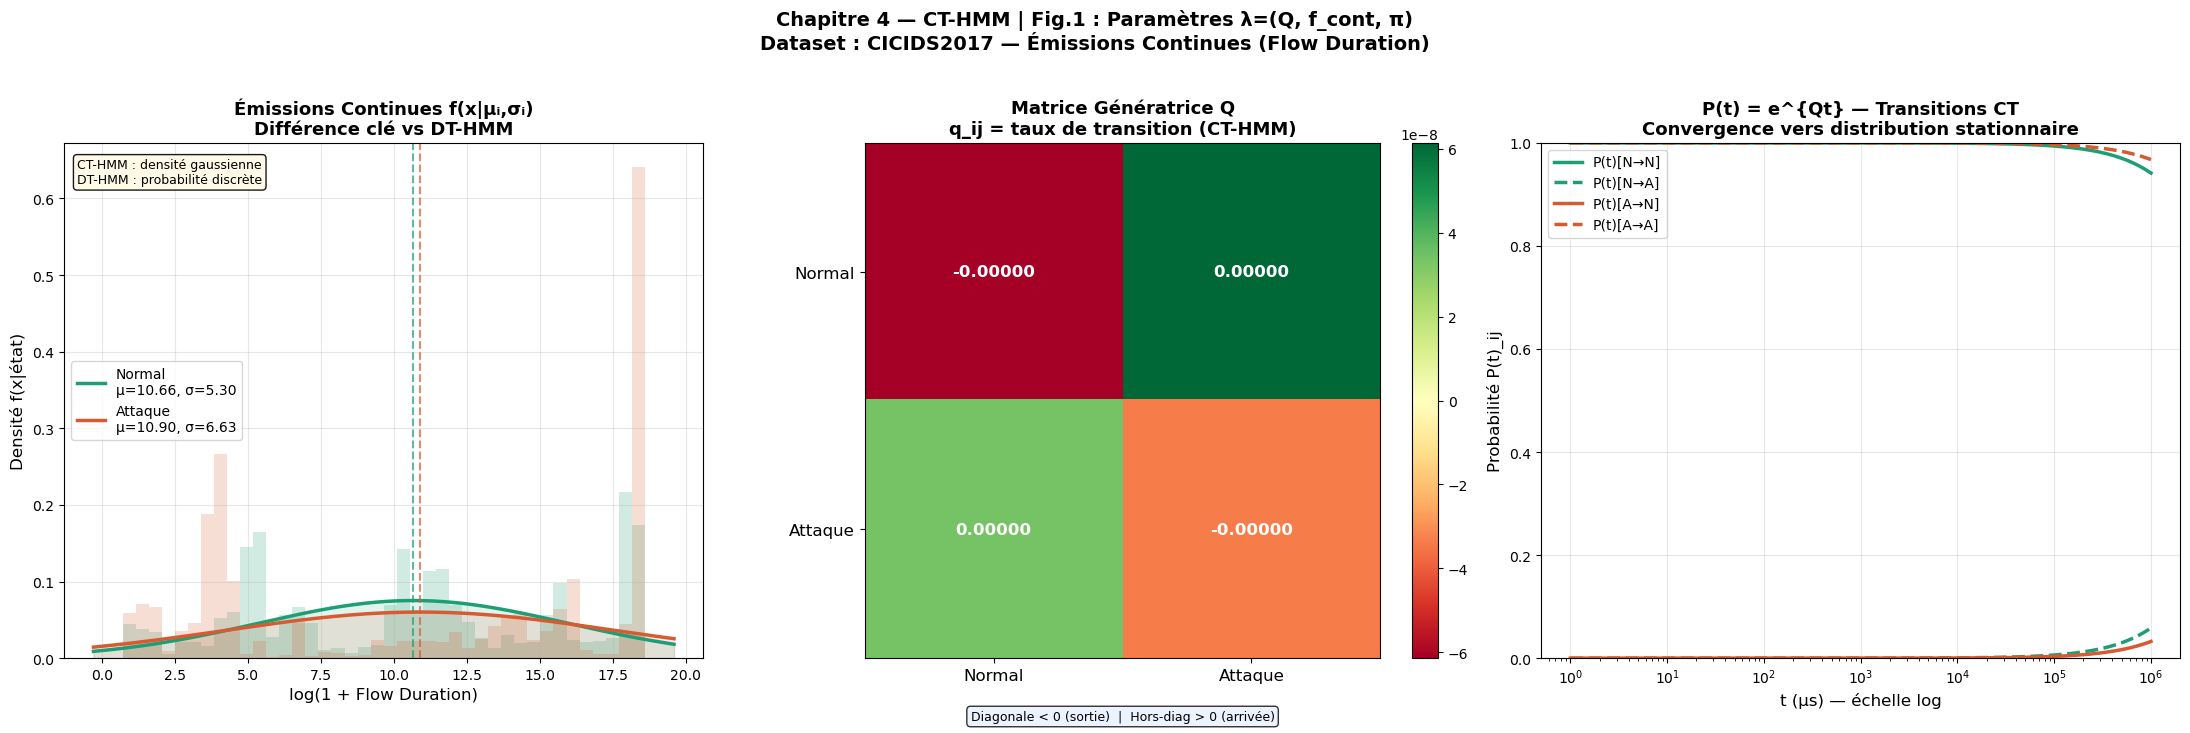


✅ Figure 1 sauvegardée


In [13]:
COUL = {0:"#1D9E75", 1:"#D85A30"}
SAVE = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\ch4'
 
# ── FIGURE 1 : Émissions continues + Matrice Q + P(t) ──
fig1, axes = plt.subplots(1, 3, figsize=(22, 7))
fig1.suptitle(
    "Chapitre 4 — CT-HMM | Fig.1 : Paramètres λ=(Q, f_cont, π)\n"
    "Dataset : CICIDS2017 — Émissions Continues (Flow Duration)",
    fontsize=14, fontweight="bold", y=1.02
)
 
# 1A : Densités gaussiennes par état
ax = axes[0]
x_range = np.linspace(
    df['obs_log'].min() - 1,
    df['obs_log'].max() + 1, 300
)
for i in range(N):
    y = emit_prob(x_range, mu_emit[i], sig_emit[i])
    ax.plot(x_range, y, color=COUL[i], lw=2.5, label=f"{ETATS[i]}\nμ={mu_emit[i]:.2f}, σ={sig_emit[i]:.2f}")
    ax.fill_between(x_range, y, alpha=0.12, color=COUL[i])
    ax.axvline(mu_emit[i], color=COUL[i], lw=1.5, ls='--', alpha=0.7)
    # Histogramme réel
    vals = df[df['etat_cache']==i]['obs_log'].values
    ax.hist(vals, bins=40, density=True, alpha=0.2, color=COUL[i])
ax.set_xlabel("log(1 + Flow Duration)", fontsize=12)
ax.set_ylabel("Densité f(x|état)", fontsize=12)
ax.set_title("Émissions Continues f(x|μᵢ,σᵢ)\nDifférence clé vs DT-HMM",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.text(0.02, 0.97,
        "CT-HMM : densité gaussienne\nDT-HMM : probabilité discrète",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', fc='#fff9e6', alpha=0.9))
 
# 1B : Matrice Q heatmap
ax = axes[1]
val_max = np.abs(Q).max()
im = ax.imshow(Q, cmap="RdYlGn", vmin=-val_max, vmax=val_max)
for i in range(N):
    for j in range(N):
        ax.text(j, i, f"{Q[i,j]:.5f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if abs(Q[i,j]) > val_max*0.5 else "black")
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels([ETATS[i] for i in range(N)], fontsize=12)
ax.set_yticklabels([ETATS[i] for i in range(N)], fontsize=12)
ax.set_title("Matrice Génératrice Q\nq_ij = taux de transition (CT-HMM)",
             fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.text(0.5, -0.12, "Diagonale < 0 (sortie)  |  Hors-diag > 0 (arrivée)",
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round', fc='#e8f0fe', alpha=0.8))
 
# 1C : P(t) = e^{Qt} convergence
ax = axes[2]
t_vals = np.logspace(0, 6, 200)
Pt00 = [expm(Q*t)[0,0] for t in t_vals]
Pt01 = [expm(Q*t)[0,1] for t in t_vals]
Pt10 = [expm(Q*t)[1,0] for t in t_vals]
Pt11 = [expm(Q*t)[1,1] for t in t_vals]
ax.semilogx(t_vals, Pt00, '-',  color=COUL[0], lw=2.5, label="P(t)[N→N]")
ax.semilogx(t_vals, Pt01, '--', color=COUL[0], lw=2.5, label="P(t)[N→A]")
ax.semilogx(t_vals, Pt10, '-',  color=COUL[1], lw=2.5, label="P(t)[A→N]")
ax.semilogx(t_vals, Pt11, '--', color=COUL[1], lw=2.5, label="P(t)[A→A]")
ax.set_xlabel("t (µs) — échelle log", fontsize=12)
ax.set_ylabel("Probabilité P(t)_ij", fontsize=12)
ax.set_title("P(t) = e^{Qt} — Transitions CT\nConvergence vers distribution stationnaire",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
 
plt.tight_layout()
plt.savefig(SAVE + r'\ch4_fig1_parametres.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Figure 1 sauvegardée")

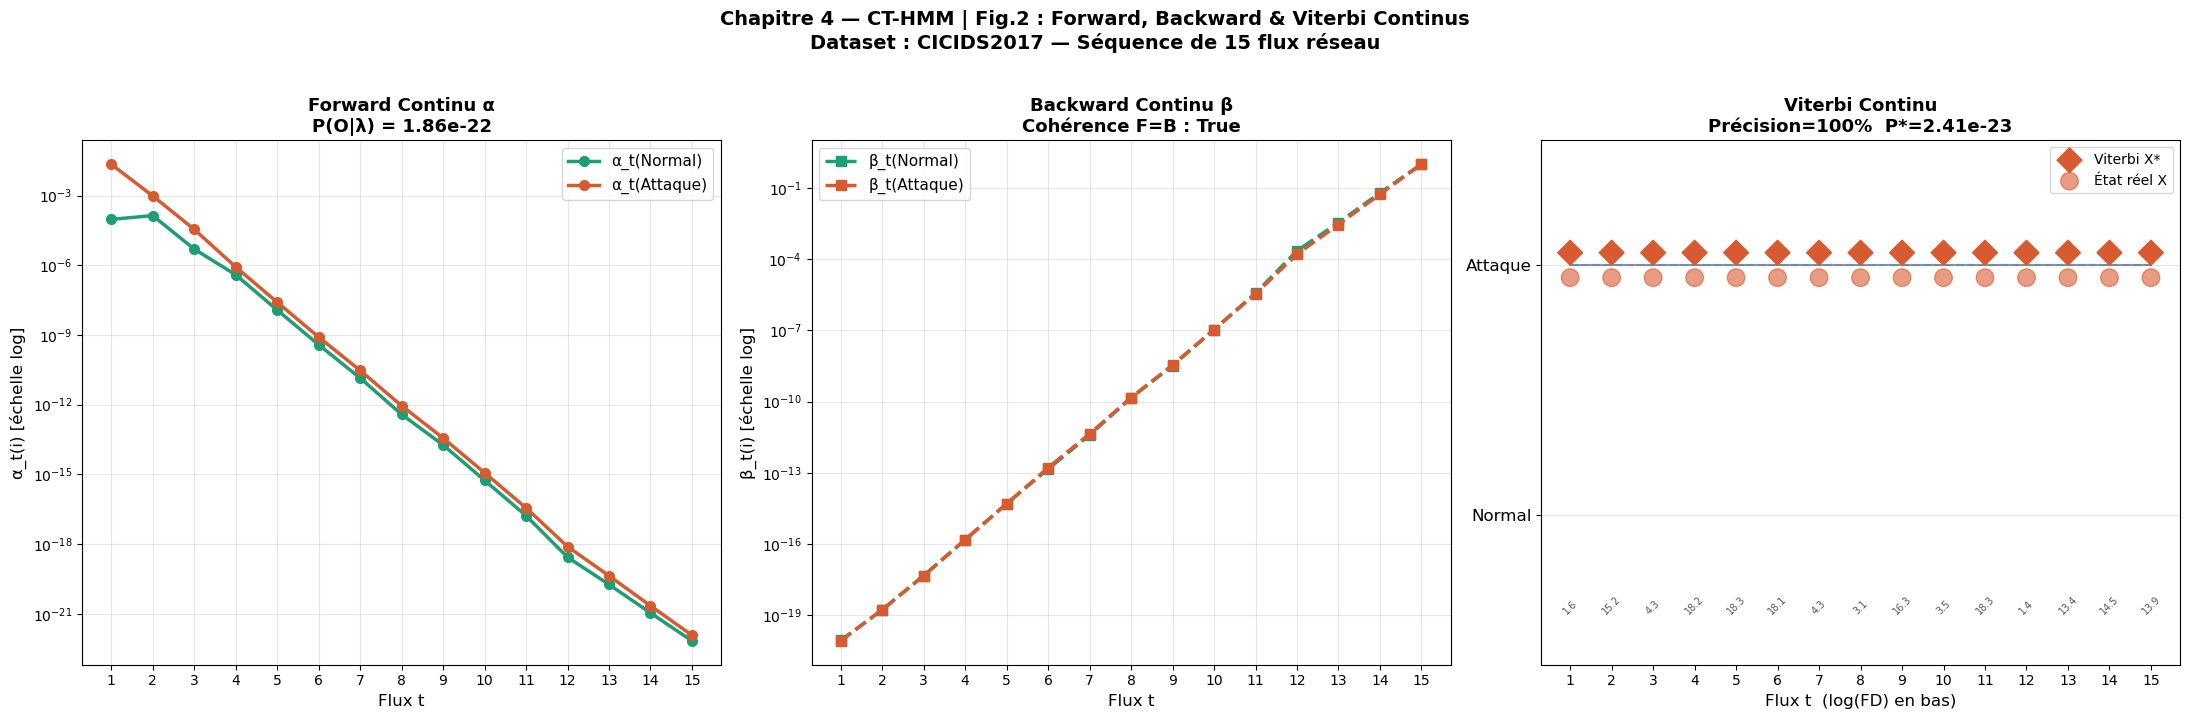

✅ Figure 2 sauvegardée


In [14]:
# ── FIGURE 2 : Forward α, Backward β, Viterbi ──
fig2, axes2 = plt.subplots(1, 3, figsize=(22, 7))
fig2.suptitle(
    "Chapitre 4 — CT-HMM | Fig.2 : Forward, Backward & Viterbi Continus\n"
    "Dataset : CICIDS2017 — Séquence de 15 flux réseau",
    fontsize=14, fontweight="bold", y=1.02
)
 
t_ax = np.arange(1, T_test+1)
 
# 2A : Forward α
ax = axes2[0]
for i in range(N):
    ax.semilogy(t_ax, alpha_ct[:, i] + 1e-300, 'o-',
                color=COUL[i], lw=2.5, markersize=7,
                label=f"α_t({ETATS[i]})")
ax.set_xlabel("Flux t", fontsize=12)
ax.set_ylabel("α_t(i) [échelle log]", fontsize=12)
ax.set_title(f"Forward Continu α\nP(O|λ) = {prob_fwd:.2e}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_xticks(t_ax)
 
# 2B : Backward β
ax = axes2[1]
for i in range(N):
    ax.semilogy(t_ax, beta_ct[:, i] + 1e-300, 's--',
                color=COUL[i], lw=2.5, markersize=7,
                label=f"β_t({ETATS[i]})")
ax.set_xlabel("Flux t", fontsize=12)
ax.set_ylabel("β_t(i) [échelle log]", fontsize=12)
ax.set_title(f"Backward Continu β\nCohérence F=B : {np.isclose(prob_fwd, prob_bwd, rtol=1e-2)}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_xticks(t_ax)
 
# 2C : Viterbi
ax = axes2[2]
ax.scatter(t_ax, seq_vit + 0.05, s=160, c=[COUL[e] for e in seq_vit],
           marker='D', zorder=4, label="Viterbi X*")
ax.scatter(t_ax, etats_test - 0.05, s=160, c=[COUL[e] for e in etats_test],
           marker='o', zorder=3, alpha=0.6, label="État réel X")
ax.step(t_ax, seq_vit,    where='mid', color='#185FA5', lw=1.5, alpha=0.6)
ax.step(t_ax, etats_test, where='mid', color='gray',    lw=1.5, ls='--', alpha=0.6)
# Obs continues en dessous
for t in range(T_test):
    ax.text(t+1, -0.4, f"{obs_test[t]:.1f}", ha='center', fontsize=7,
            color='#555', rotation=45)
ax.set_yticks([0, 1])
ax.set_yticklabels([ETATS[i] for i in range(N)], fontsize=12)
ax.set_xlabel("Flux t  (log(FD) en bas)", fontsize=12)
ax.set_title(f"Viterbi Continu\nPrécision={acc_vit*100:.0f}%  P*={prob_vit:.2e}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xticks(t_ax); ax.set_ylim(-0.6, 1.5)
ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig(SAVE + r'\ch4_fig2_algorithmes.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure 2 sauvegardée")

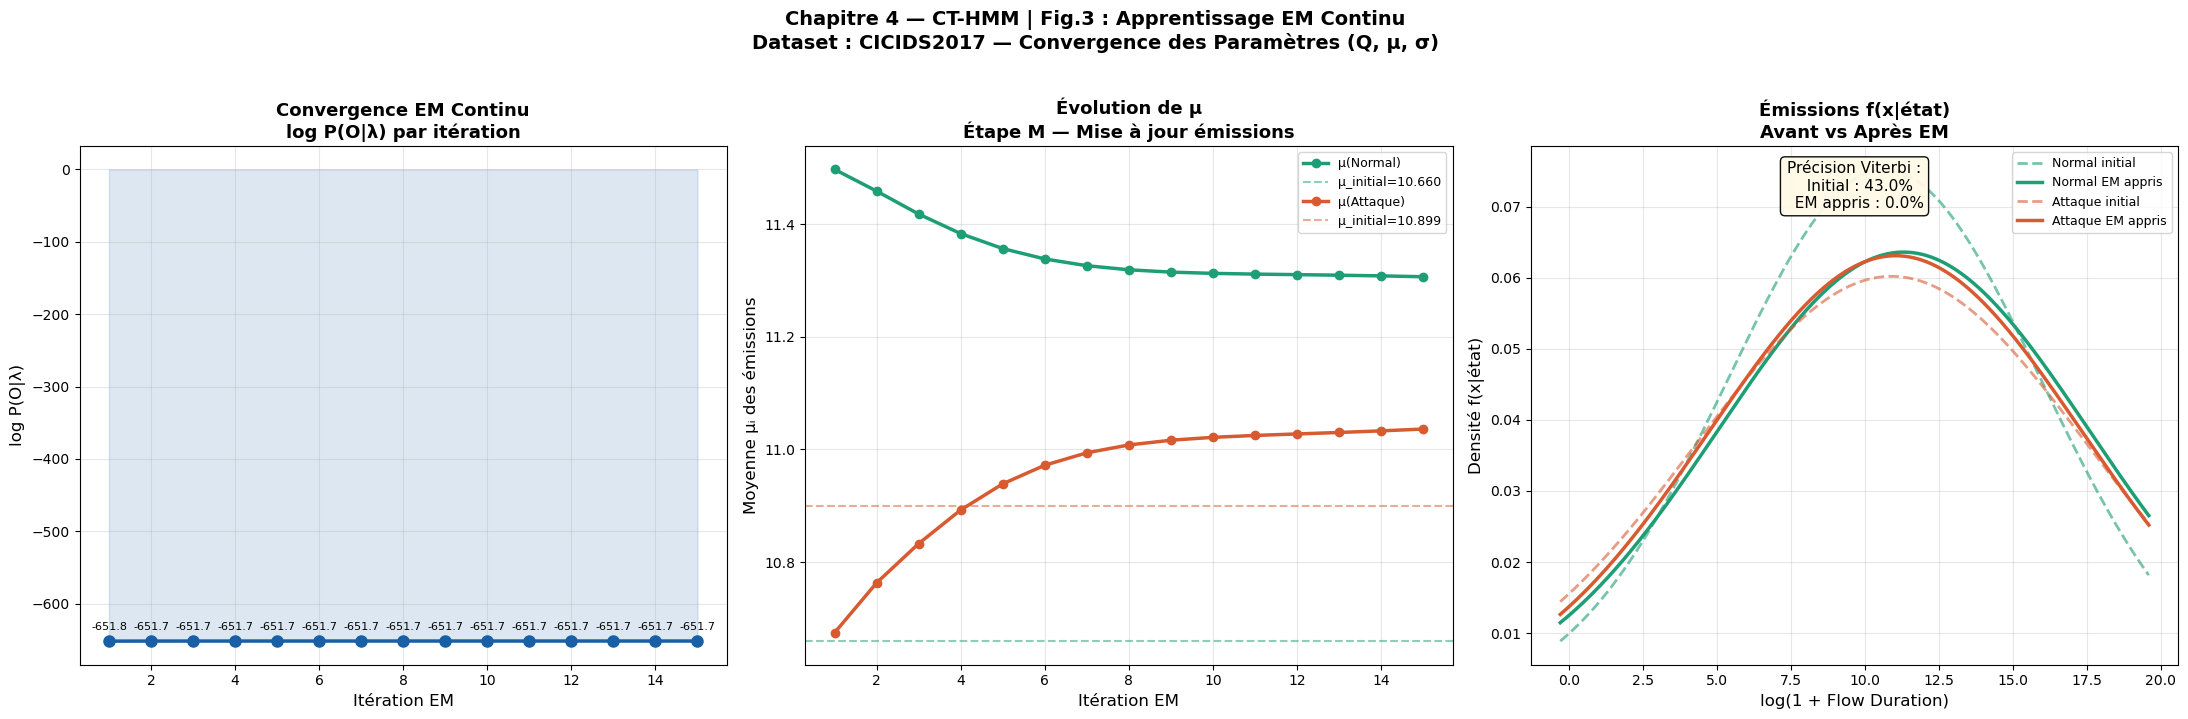

✅ Figure 3 sauvegardée

🎉 CHAPITRE 4 CT-HMM COMPLET !


In [15]:
# ── FIGURE 3 : EM convergence + comparaison μ/σ ──
fig3, axes3 = plt.subplots(1, 3, figsize=(22, 7))
fig3.suptitle(
    "Chapitre 4 — CT-HMM | Fig.3 : Apprentissage EM Continu\n"
    "Dataset : CICIDS2017 — Convergence des Paramètres (Q, μ, σ)",
    fontsize=14, fontweight="bold", y=1.02
)
 
# 3A : Log-vraisemblance
ax = axes3[0]
ax.plot(range(1, len(log_hist)+1), log_hist, 'o-',
        color="#185FA5", lw=2.5, markersize=8)
ax.fill_between(range(1, len(log_hist)+1), log_hist, alpha=0.15, color="#185FA5")
ax.set_xlabel("Itération EM", fontsize=12)
ax.set_ylabel("log P(O|λ)", fontsize=12)
ax.set_title("Convergence EM Continu\nlog P(O|λ) par itération",
             fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
for it, val in enumerate(log_hist):
    ax.annotate(f"{val:.1f}", (it+1, val),
                textcoords="offset points", xytext=(0,8),
                ha='center', fontsize=8)
 
# 3B : Évolution μ
ax = axes3[1]
iters = range(1, len(mu_hist)+1)
for i in range(N):
    ax.plot(iters, [mu_hist[it][i] for it in range(len(mu_hist))],
            'o-', color=COUL[i], lw=2.5, label=f"μ({ETATS[i]})")
    ax.axhline(mu_emit[i], color=COUL[i], ls='--', lw=1.5, alpha=0.5,
               label=f"μ_initial={mu_emit[i]:.3f}")
ax.set_xlabel("Itération EM", fontsize=12)
ax.set_ylabel("Moyenne μᵢ des émissions", fontsize=12)
ax.set_title("Évolution de μ\nÉtape M — Mise à jour émissions",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
 
# 3C : Comparaison densités avant/après EM
ax = axes3[2]
x_r = np.linspace(df['obs_log'].min()-1, df['obs_log'].max()+1, 300)
for i in range(N):
    y_init = emit_prob(x_r, mu_emit[i], sig_emit[i])
    y_em   = emit_prob(x_r, mu_em[i], sig_em[i])
    ax.plot(x_r, y_init, '--', color=COUL[i], lw=2, alpha=0.6,
            label=f"{ETATS[i]} initial")
    ax.plot(x_r, y_em,   '-',  color=COUL[i], lw=2.5,
            label=f"{ETATS[i]} EM appris")
ax.set_xlabel("log(1 + Flow Duration)", fontsize=12)
ax.set_ylabel("Densité f(x|état)", fontsize=12)
ax.set_title("Émissions f(x|état)\nAvant vs Après EM",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.text(0.5, 0.97,
        f"Précision Viterbi :\n"
        f"  Initial : {acc_init*100:.1f}%\n"
        f"  EM appris : {acc_em*100:.1f}%",
        transform=ax.transAxes, ha='center', va='top', fontsize=11,
        bbox=dict(boxstyle='round', fc='#fff9e6', alpha=0.95))
 
plt.tight_layout()
plt.savefig(SAVE + r'\ch4_fig3_em_continu.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure 3 sauvegardée")
print("\n🎉 CHAPITRE 4 CT-HMM COMPLET !")